# Introduction

The goal of this project is to create a predictive model for coral bleaching events, using data collected from the Great Barrier Reef, Red Sea, South China Sea, Hawaiian Islands, Caribbean Sea, Galapagos, and Maldives. The dataset includes records of sea surface temperature, pH, bleaching severity, observed species, and marine heatwaves for 2013-2023. 

In [2]:
# loading data and libraries
import pandas as pd
file_path = '/kaggle/input/datasets/lindsaysmith13/oceans-dataset/realistic_ocean_climate_dataset.csv'
df = pd.read_csv(file_path)

# Count the number of records per location
location_counts = df['Location'].value_counts()
print(location_counts)

Location
Great Barrier Reef    87
Red Sea               83
South China Sea       73
Hawaiian Islands      71
Caribbean Sea         70
Galápagos             65
Maldives              51
Name: count, dtype: int64


# Feature Engineering

In [3]:
# Convert Date to a datetime and sort 
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values(by=['Location', 'Date'])

# Defining binary target, bleaching severity - high, medium = 1, none, low = 0
df['Bleaching_Event'] = df['Bleaching Severity'].apply(lambda x: 1 if x in ['High', 'Medium'] else 0)

Prolonged heat stress is a cause of bleaching. The Degree Heating Weeks (DHW) creates a rolling feature of prolonged hot SSTs.

In [4]:
# Group by location to isolate averages, etc 
def calculate_dhw(group):
    historical_mean_sst = group['SST (°C)'].mean()
    # Calculating the "anomaly", if < average, cap it at 0 (no heat stress)
    group['Temp_Anomaly'] = (group['SST (°C)'] - historical_mean_sst).clip(lower=0)
    # Calculate DHW (12-week sum of anomalies)
    group['Heat_Stress_12Wk'] = group['Temp_Anomaly'].rolling(window=12, min_periods=1).sum()
    return group

df = df.groupby('Location').apply(calculate_dhw, include_groups=False).reset_index(level='Location').reset_index(drop=True)

# EDA

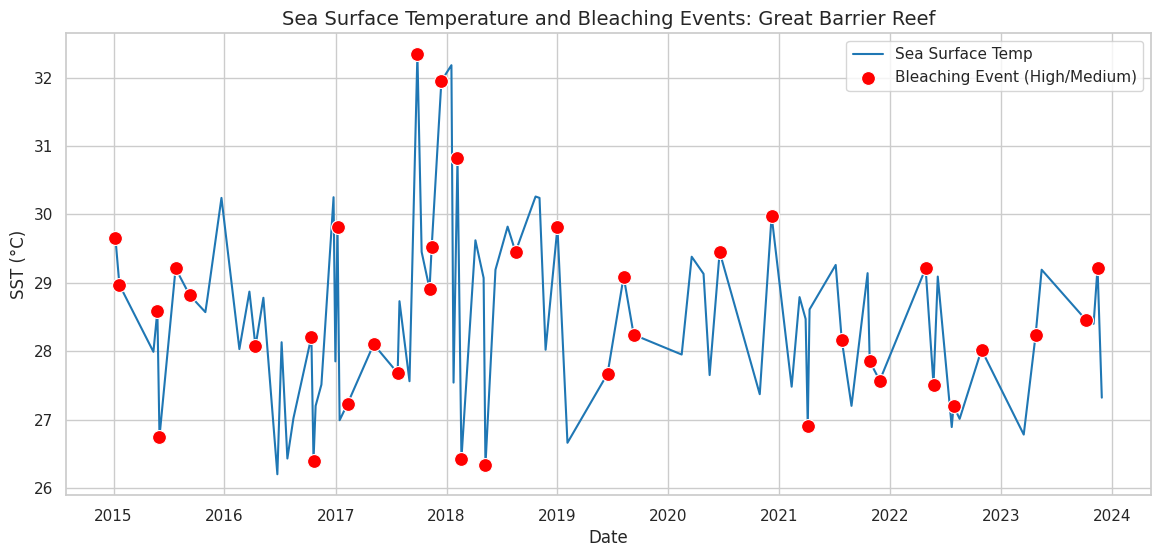

In [5]:
# Create a scatterplot for SST over time, overlay of bleaching events
import matplotlib.pyplot as plt
import seaborn as sns


sns.set_theme(style="whitegrid")

top_location = 'Great Barrier Reef'
df_loc = df[df['Location'] == top_location]

plt.figure(figsize=(14, 6))
sns.lineplot(data=df_loc, x='Date', y='SST (°C)', label='Sea Surface Temp', color='#1f77b4', linewidth=1.5)
bleaching_events = df_loc[df_loc['Bleaching_Event'] == 1]
sns.scatterplot(data=bleaching_events, x='Date', y='SST (°C)', color='red', s=100, 
                label='Bleaching Event (High/Medium)', zorder=5)

plt.title(f'Sea Surface Temperature and Bleaching Events: {top_location}', fontsize=14)
plt.xlabel('Date', fontsize=12)
plt.ylabel('SST (°C)', fontsize=12)
plt.legend()
plt.show()

Results show a very weak correlation between SST and bleaching events - I'm assuming that's because SST would vary seasonally. 

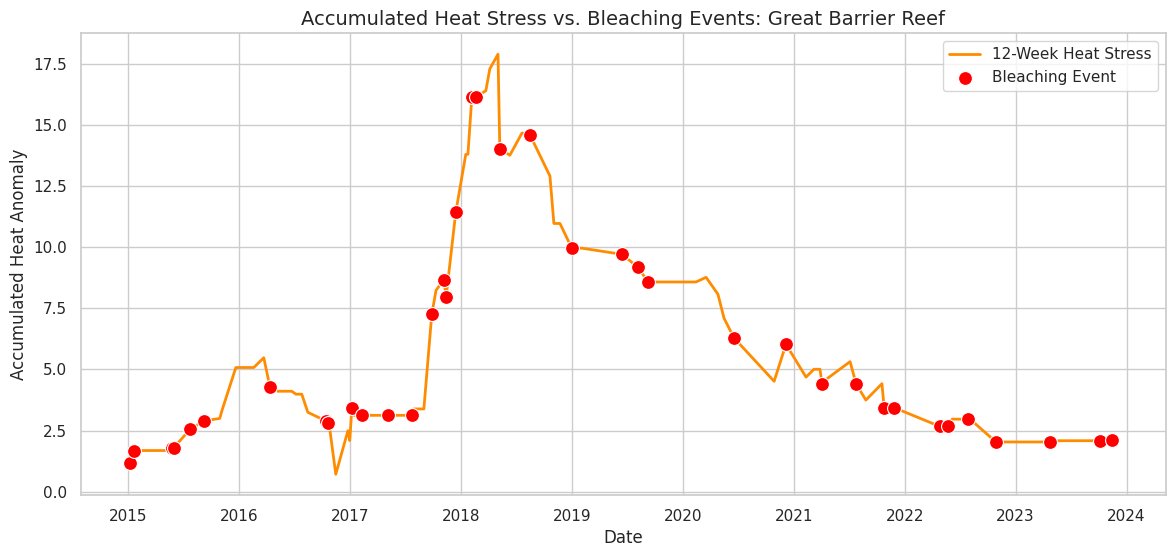

In [6]:
# Create scatterplot for heat stress 
plt.figure(figsize=(14, 6))
sns.lineplot(data=df_loc, x='Date', y='Heat_Stress_12Wk', label='12-Week Heat Stress', color='darkorange', linewidth=2)

sns.scatterplot(data=bleaching_events, x='Date', y='Heat_Stress_12Wk', color='red', s=100, 
                label='Bleaching Event', zorder=5)

plt.title(f'Accumulated Heat Stress vs. Bleaching Events: {top_location}', fontsize=14)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Accumulated Heat Anomaly', fontsize=12)
plt.legend()
plt.show()

Results show a much stronger correlation between accumulated heat stress and bleaching events. The two plots support the idea that corals can handle a few days of anomalous heat, but extended periods of heat coincide with bleaching events. 

# Model Training

In [7]:
from sklearn.model_selection import train_test_split

features = ['SST (°C)', 'pH Level', 'Marine Heatwave', 'Heat_Stress_12Wk']
X = df[features]
y = df['Bleaching_Event']
# stratify=y ensure train & test sets have same ratio bleaching events
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [8]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

# Train Random Forest
rf_model = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.56      0.71      0.63        56
           1       0.45      0.30      0.36        44

    accuracy                           0.53       100
   macro avg       0.51      0.50      0.49       100
weighted avg       0.51      0.53      0.51       100



The baseline Random Forest struggled to identify bleaching events globally (Recall: 0.30), indicating that raw environmental data without regional calibration or threshold adjustments is insufficient.

# Model Adjustments

In [9]:
# Adjusting decision threshold

y_pred_probs = rf_model.predict_proba(X_test)[:, 1]

# Lower threshold from 50 to 30%
custom_threshold = 0.30
y_pred_adjusted = (y_pred_probs >= custom_threshold).astype(int)

print("Results with Lowered Threshold (0.30): ")
print(classification_report(y_test, y_pred_adjusted))

Results with Lowered Threshold (0.30): 
              precision    recall  f1-score   support

           0       0.42      0.25      0.31        56
           1       0.37      0.57      0.45        44

    accuracy                           0.39       100
   macro avg       0.40      0.41      0.38       100
weighted avg       0.40      0.39      0.37       100



In [10]:
# Hyperparameter Tuning
from sklearn.model_selection import GridSearchCV

# Define a grid of parameters
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 10, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

grid_search = GridSearchCV(
    estimator=RandomForestClassifier(class_weight='balanced', random_state=42),
    param_grid=param_grid,
    scoring='recall', 
    cv=3, 
    n_jobs=-1 
)

# Fit to data
grid_search.fit(X_train, y_train)

best_rf_model = grid_search.best_estimator_
print(f"Best Parameters Found: {grid_search.best_params_}\n")

# Predict with new model
y_pred_tuned = best_rf_model.predict(X_test)
print("Results with Hyperparameter Tuning: ")
print(classification_report(y_test, y_pred_tuned))

Best Parameters Found: {'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 10, 'n_estimators': 200}

Results with Hyperparameter Tuning: 
              precision    recall  f1-score   support

           0       0.54      0.61      0.57        56
           1       0.41      0.34      0.37        44

    accuracy                           0.49       100
   macro avg       0.47      0.47      0.47       100
weighted avg       0.48      0.49      0.48       100



In [12]:
# Training model on a single region, the Great Barrier Reef was chosen as it had the most data

region = 'Great Barrier Reef'
df_regional = df[df['Location'] == region].copy()

X_reg = df_regional[features]
y_reg = df_regional['Bleaching_Event']
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42, stratify=y_reg
)

rf_regional = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
rf_regional.fit(X_train_reg, y_train_reg)

y_pred_reg = rf_regional.predict(X_test_reg)
print(f"Results for Regional Model:")
print(classification_report(y_test_reg, y_pred_reg))

Results for Regional Model:
              precision    recall  f1-score   support

           0       0.64      0.70      0.67        10
           1       0.57      0.50      0.53         8

    accuracy                           0.61        18
   macro avg       0.60      0.60      0.60        18
weighted avg       0.61      0.61      0.61        18



### Analysis of model adjustments
- Lowering the threshold did increase recall (+27%), but at the cost of accuracy and precision. The number of false alarms that would be caused by this model makes it a poor choice.
- Hyperparameter tuning only increased recall by 4%. With a max depth of 5, the original model was most likely overfitting the data. This shows that global ocean data is too diverse for one simple model.
- Choosing a single region was the best of the three methods. Recall increased to 0.50, precision to 0.57, and accuracy to 0.61. While this model performed the best, the very limited sample size (18) shows that the next logical step is to include historical data.

In [13]:
# Final model, incorporating the different methods

# Using only Great Barrier Reef data

# Apply the best parameters from Grid Search

final_rf = RandomForestClassifier(
    n_estimators=200, 
    max_depth=5,
    min_samples_split=10,
    min_samples_leaf=1,
    class_weight='balanced', 
    random_state=42
)

final_rf.fit(X_train_reg, y_train_reg)

y_pred_probs_final = final_rf.predict_proba(X_test_reg)[:, 1]

# 4. Set threshold to 0.4, more conservative than before 
optimal_threshold = 0.40
y_pred_final = (y_pred_probs_final >= optimal_threshold).astype(int)


print(f"Results for Tuned Regional Model (Threshold = {optimal_threshold}):")
print(classification_report(y_test_reg, y_pred_final))

importances_final = pd.DataFrame({
    'Feature': X_train_reg.columns,
    'Importance': final_rf.feature_importances_
}).sort_values(by='Importance', ascending=False)

print("\nFeature Importances for Final Model:")
print(importances_final)

Results for Tuned Regional Model (Threshold = 0.4):
              precision    recall  f1-score   support

           0       0.50      0.40      0.44        10
           1       0.40      0.50      0.44         8

    accuracy                           0.44        18
   macro avg       0.45      0.45      0.44        18
weighted avg       0.46      0.44      0.44        18


Feature Importances for Final Model:
            Feature  Importance
3  Heat_Stress_12Wk    0.368334
1          pH Level    0.317421
0          SST (°C)    0.294973
2   Marine Heatwave    0.019272


# Conclusion

While the overall accuracy of 44% is not ideal, the engineered 'heat_stress_12Wk' was the best predictor of coral bleaching. The model confirms that prolonged, accumulating heat stress and ocean acidification (pH) are much stronger indicators of ecosystem collapse than simple temperature spikes. To continue building a more accurate model, historical data should be used to beef up the existing dataset. 